# 06E v2 - Resume Cache And Continue Training

Notebook này là bản tiếp tục cho `06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_SER`.

Mục tiêu chính:
- Tự tìm cache/partial cache đã tải lên Kaggle Input.
- Chép cache về `/kaggle/working/.../cache` trước khi trích xuất đặc trưng.
- Nếu cache thiếu một vài mẫu, notebook chỉ trích xuất nốt các mẫu còn thiếu rồi assemble thành full cache.
- Sau khi full feature cache hoàn chỉnh, notebook chạy train/evaluate như bản 06E.

Lưu ý quan trọng: cache chỉ khớp nếu dùng cùng `ser_processed`, cùng `TARGET_DURATION`, `N_MFCC`, `N_MELS`, `RUN_EMOTION2VEC` và không đổi thứ tự metadata.

## Ý Tưởng Và Paper Reference

### 1. emotion2vec frozen embedding

`emotion2vec` học biểu diễn cảm xúc phổ quát từ speech. Notebook giữ mô hình pretrained ở chế độ **frozen**, chỉ train adapter/classifier nhỏ phía sau. Điều này phù hợp với demo thực tế vì giảm nguy cơ overfit vào speaker/dataset của project.

Reference:

- emotion2vec: Self-Supervised Pre-Training for Speech Emotion Representation, https://arxiv.org/abs/2312.15185
- ModelScope emotion2vec, https://www.modelscope.cn/models/iic/emotion2vec_base

### 2. Richer statistical features

Các hệ SER dựa trên feature engineering mạnh thường không chỉ dùng MFCC mean/std, mà còn khai thác prosody, pitch, energy dynamics, timbre và segment-level patterns. Vì `stats_rbf_svm` trong 06D yếu, 06E mở rộng statistical vector để nhánh này có nhiều tín hiệu emotion hơn.

Reference:

- Ahmed et al. ensemble 1D-CNN/CNN-LSTM/CNN-GRU, https://arxiv.org/abs/2112.05666
- Ullah et al. feature fusion 1D-CNN, https://doi.org/10.1109/ICIT56493.2022.9989197

### 3. Train-only waveform augmentation

Augmentation chỉ được áp dụng cho train split. Không augment validation/test để tránh leakage. 06E dùng noise, gain, time shift, pitch shift và time stretch nhẹ. Sau augmentation, notebook trích lại toàn bộ feature, kể cả emotion2vec embedding.

Reference:

- SpecAugment, https://arxiv.org/abs/1904.08779
- mixup, https://arxiv.org/abs/1710.09412

### 4. Multi-level acoustic co-attention

06D chỉ dùng vector-level fusion. 06E tạo nhiều acoustic tokens:

```text
temporal_low, temporal_high, spectral_low, spectral_high
```

Sau đó dùng self-attention nhẹ giữa các acoustic tokens, rồi dùng `emotion2vec` làm query để chọn acoustic information phù hợp nhất.

Reference:

- CA-MSER: Speech Emotion Recognition with Co-Attention based Multi-level Acoustic Information, https://arxiv.org/abs/2203.15326


## Kiến Trúc Full 06E

```text
Input audio 16 kHz
   |
   |-- Branch A: Temporal acoustic
   |      MFCC + delta + delta-delta + RMS/ZCR/spectral sequence
   |      -> 1D-CNN
   |      -> low temporal token
   |      -> BiLSTM -> attention pooling
   |      -> high temporal token
   |
   |-- Branch B: Spectrogram
   |      log-Mel + delta log-Mel + delta-delta log-Mel
   |      -> early 2D-CNN/SE
   |      -> low spectral token
   |      -> deeper 2D-CNN/SE
   |      -> high spectral token
   |
   |-- Branch C: Emotion pretrained
   |      raw waveform
   |      -> frozen emotion2vec
   |      -> adapter MLP
   |      -> z_emotion2vec
   |
   |-- Branch D: Rich statistical
          global stats + segment stats + pitch/prosody + chroma/timbre
          -> Stats MLP -> z_stats
          -> RBF-SVM -> p_stats

Fusion:
   [temporal_low, temporal_high, spectral_low, spectral_high]
   -> acoustic self-attention
   -> emotion2vec-guided cross-attention
   -> fusion MLP
   -> p_deep

Final:
   stacking(p_deep, p_stats, p_emotion2vec_logreg, p_emotion2vec_mlp)
   -> 6 emotions
```

6 labels:

```text
neutral, happy, sad, angry, fear, disgust
```


## Kaggle Run Guide

Dataset cần add vào notebook:

1. `ser_processed` có `metadata.csv` và tốt nhất có `audio_16k/`.
2. Bật Internet nếu muốn tự tải `funasr/modelscope` và model emotion2vec.

Quick smoke test:

```text
QUICK_RUN=1
MAX_EPOCHS=1
RUN_EMOTION2VEC=0
USE_WAVEFORM_TRAIN_AUGMENTATION=0
```

Full run đề xuất:

```text
QUICK_RUN=0
RUN_EMOTION2VEC=1
INSTALL_EMOTION2VEC_DEPS=1
USE_WAVEFORM_TRAIN_AUGMENTATION=1
AUGMENT_COPIES=1
MAX_EPOCHS=35
RUN_COMBINED_RANDOM=1
RUN_COMBINED_STRICT=1
RUN_SINGLE_DATASET=0
```

Nếu Kaggle thiếu RAM/thời gian, chạy trước:

```text
USE_WAVEFORM_TRAIN_AUGMENTATION=0
BATCH_SIZE=16
```

Nếu mạng/Kaggle dễ rớt, notebook 06E đã có checkpoint từng phần:

```text
PARTIAL_SAVE_EVERY=100
```

Trong lúc extract, cache sẽ được lưu dần vào:

```text
.../cache/<cache_name>_parts/part_*.npz
```

Nếu kernel chết, chạy lại notebook sẽ tự đọc các part đã có và tiếp tục từ mẫu còn thiếu.



In [1]:
# Optional dependency install for Kaggle.
# Turn this off if your environment already has funasr/modelscope.
import os, sys, subprocess, importlib.util

INSTALL_EMOTION2VEC_DEPS = os.getenv("INSTALL_EMOTION2VEC_DEPS", "1") == "1"
NEEDED = ["funasr", "modelscope"]
missing = [pkg for pkg in NEEDED if importlib.util.find_spec(pkg) is None]

if INSTALL_EMOTION2VEC_DEPS and missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "funasr", "modelscope", "addict", "simplejson", "sortedcontainers"])
else:
    print("Dependency install skipped or already available.")


Installing missing packages: ['funasr', 'modelscope']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.8/298.8 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.2/926.2 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 8.2 MB/s eta 0:00:00


In [2]:
import os
import json
import time
import math
import random
import shutil
import zipfile
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score, classification_report, confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = int(os.getenv("SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
USE_MULTI_GPU = os.getenv("USE_MULTI_GPU", "0") == "1"
torch.backends.cudnn.benchmark = False

def maybe_data_parallel(model, name="model"):
    if USE_MULTI_GPU and GPU_COUNT > 1:
        print(f"Using DataParallel for {name} on {GPU_COUNT} GPUs")
        return nn.DataParallel(model)
    return model

print("Device:", DEVICE)
print("GPU_COUNT:", GPU_COUNT, "USE_MULTI_GPU:", USE_MULTI_GPU)


Device: cuda
GPU_COUNT: 2 USE_MULTI_GPU: False


In [3]:
QUICK_RUN = os.getenv("QUICK_RUN", "0") == "1"
QUICK_RUN_PER_DATASET = int(os.getenv("QUICK_RUN_PER_DATASET", "90"))

TARGET_SR = 16_000
TARGET_DURATION = float(os.getenv("TARGET_DURATION", "3.0"))
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

N_FFT = int(os.getenv("N_FFT", "400"))
WIN_LENGTH = int(os.getenv("WIN_LENGTH", "400"))
HOP_LENGTH = int(os.getenv("HOP_LENGTH", "160"))
N_MFCC = int(os.getenv("N_MFCC", "40"))
N_MELS = int(os.getenv("N_MELS", "96"))
MAX_FRAMES = int(1 + TARGET_LENGTH // HOP_LENGTH)

COMMON_EMOTIONS = ["neutral", "happy", "sad", "angry", "fear", "disgust"]
LABEL_TO_ID = {label: i for i, label in enumerate(COMMON_EMOTIONS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

BATCH_SIZE = int(os.getenv("BATCH_SIZE", "20"))
MAX_EPOCHS = int(os.getenv("MAX_EPOCHS", "35"))
PATIENCE = int(os.getenv("PATIENCE", "7"))
LR = float(os.getenv("LR", "7e-4"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "5e-4"))
DROPOUT = float(os.getenv("DROPOUT", "0.40"))
LABEL_SMOOTHING = float(os.getenv("LABEL_SMOOTHING", "0.06"))

RUN_COMBINED_RANDOM = os.getenv("RUN_COMBINED_RANDOM", "1") == "1"
RUN_COMBINED_STRICT = os.getenv("RUN_COMBINED_STRICT", "1") == "1"
RUN_SINGLE_DATASET = os.getenv("RUN_SINGLE_DATASET", "0") == "1"

RUN_EMOTION2VEC = os.getenv("RUN_EMOTION2VEC", "1") == "1"
EMOTION2VEC_MODEL = os.getenv("EMOTION2VEC_MODEL", "iic/emotion2vec_base")
ALLOW_ZERO_EMOTION2VEC_FOR_DEBUG = os.getenv("ALLOW_ZERO_EMOTION2VEC_FOR_DEBUG", "1") == "1"

USE_AUGMENTATION = os.getenv("USE_AUGMENTATION", "1") == "1"
SPECTRAL_AUG_PROB = float(os.getenv("SPECTRAL_AUG_PROB", "0.45"))
TEMPORAL_AUG_PROB = float(os.getenv("TEMPORAL_AUG_PROB", "0.35"))

USE_WAVEFORM_TRAIN_AUGMENTATION = os.getenv("USE_WAVEFORM_TRAIN_AUGMENTATION", "1") == "1"
AUGMENT_COPIES = int(os.getenv("AUGMENT_COPIES", "1"))
DELETE_AUG_WAV_AFTER_EMBED = os.getenv("DELETE_AUG_WAV_AFTER_EMBED", "1") == "1"

USE_CLASS_WEIGHTS = os.getenv("USE_CLASS_WEIGHTS", "1") == "1"
USE_BALANCED_SAMPLER = os.getenv("USE_BALANCED_SAMPLER", "1") == "1"

RUN_STATS_SVM = os.getenv("RUN_STATS_SVM", "1") == "1"
RUN_E2V_LOGREG = os.getenv("RUN_E2V_LOGREG", "1") == "1"
RUN_E2V_MLP = os.getenv("RUN_E2V_MLP", "1") == "1"
RUN_E2V_RBF_SVM = os.getenv("RUN_E2V_RBF_SVM", "0") == "1"
STATS_PCA_COMPONENTS = int(os.getenv("STATS_PCA_COMPONENTS", "320"))
E2V_PCA_COMPONENTS = int(os.getenv("E2V_PCA_COMPONENTS", "192"))

print({
    "QUICK_RUN": QUICK_RUN,
    "TARGET_DURATION": TARGET_DURATION,
    "MAX_EPOCHS": MAX_EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "RUN_EMOTION2VEC": RUN_EMOTION2VEC,
    "EMOTION2VEC_MODEL": EMOTION2VEC_MODEL,
    "USE_WAVEFORM_TRAIN_AUGMENTATION": USE_WAVEFORM_TRAIN_AUGMENTATION,
    "AUGMENT_COPIES": AUGMENT_COPIES,
    "RUN_COMBINED_RANDOM": RUN_COMBINED_RANDOM,
    "RUN_COMBINED_STRICT": RUN_COMBINED_STRICT,
    "RUN_SINGLE_DATASET": RUN_SINGLE_DATASET,
})


{'QUICK_RUN': False, 'TARGET_DURATION': 3.0, 'MAX_EPOCHS': 35, 'BATCH_SIZE': 20, 'RUN_EMOTION2VEC': True, 'EMOTION2VEC_MODEL': 'iic/emotion2vec_base', 'USE_WAVEFORM_TRAIN_AUGMENTATION': True, 'AUGMENT_COPIES': 1, 'RUN_COMBINED_RANDOM': True, 'RUN_COMBINED_STRICT': True, 'RUN_SINGLE_DATASET': False}


In [4]:
def find_ser_processed():
    candidates = []
    env_path = os.getenv("SER_PROCESSED", "").strip()
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend([
        Path("/kaggle/input/datasets/quanghuy225/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed"),
        Path("/kaggle/working/ser_processed"),
        Path.cwd() / "ser_processed",
        Path.cwd().parent / "ser_processed",
        Path.cwd().parent / "01&02_Data_and_DataProcessing" / "ser_processed",
        Path("D:/UTE/Speech Programming/Speech Project/01&02_Data_and_DataProcessing/ser_processed"),
    ])
    for candidate in candidates:
        if (candidate / "metadata.csv").exists():
            return candidate.resolve()
    for root in [Path("/kaggle/input"), Path.cwd(), Path.cwd().parent]:
        if root.exists():
            for metadata_path in root.rglob("metadata.csv"):
                if metadata_path.parent.name == "ser_processed":
                    return metadata_path.parent.resolve()
    raise FileNotFoundError("Cannot find ser_processed/metadata.csv")

SER_PROCESSED = find_ser_processed()
AUDIO_16K_DIR = SER_PROCESSED / "audio_16k"
PROJECT_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
CACHE_DIR = OUTPUT_DIR / "cache"
AUG_TMP_DIR = PROJECT_ROOT / "06E_aug_tmp_wavs"
for d in [REPORT_DIR, FIGURE_DIR, MODEL_DIR, PRED_DIR, CACHE_DIR, AUG_TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("SER_PROCESSED:", SER_PROCESSED)
print("AUDIO_16K_DIR exists:", AUDIO_16K_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)


SER_PROCESSED: /kaggle/input/datasets/linhlaz225/ser-processed/ser_processed
AUDIO_16K_DIR exists: True
OUTPUT_DIR: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs


## Restore Partial Cache From Kaggle Input

Khi Kaggle bị mất mạng hoặc kernel chết giữa chừng, phần cache đã sinh ra trong Output có thể tải về rồi upload lại thành Kaggle Dataset. Block dưới đây sẽ tự tìm các file/cache parts đó trong `/kaggle/input`, sau đó copy về đúng thư mục cache trong `/kaggle/working`.

Nên bật mặc định:
- `RESTORE_06E_CACHE_FROM_INPUT=1`: tự phục hồi cache từ Kaggle Input.
- `PARTIAL_SAVE_EVERY=10`: lưu checkpoint thường xuyên hơn để nếu chết kernel thì mất ít tiến độ.
- Nếu chỉ muốn hoàn tất cache nền trước, có thể đặt `USE_WAVEFORM_TRAIN_AUGMENTATION=0`; sau khi base cache đã hoàn chỉnh thì bật lại để chạy augmentation train-only.

In [5]:
RESTORE_06E_CACHE_FROM_INPUT = os.getenv("RESTORE_06E_CACHE_FROM_INPUT", "1") == "1"
RESTORED_06E_CACHE_ROOT = os.getenv("RESTORED_06E_CACHE_ROOT", "").strip()
RESTORED_06E_CACHE_DATASET = os.getenv("RESTORED_06E_CACHE_DATASET", "").strip()

def _copy_file_if_needed(src, dst):
    src = Path(src)
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    if (not dst.exists()) or src.stat().st_size != dst.stat().st_size:
        shutil.copy2(src, dst)
        return 1
    return 0

def _copy_tree_if_needed(src_dir, dst_dir):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    copied = 0
    for src in src_dir.rglob("*"):
        if src.is_file():
            copied += _copy_file_if_needed(src, dst_dir / src.relative_to(src_dir))
    return copied

def _unique_existing_paths(paths):
    unique = []
    seen = set()
    for path in paths:
        try:
            resolved = Path(path).resolve()
        except Exception:
            continue
        if resolved.exists() and resolved not in seen:
            unique.append(resolved)
            seen.add(resolved)
    return unique

def _candidate_restore_roots():
    roots = []
    if RESTORED_06E_CACHE_ROOT:
        roots.append(Path(RESTORED_06E_CACHE_ROOT))

    input_root = Path("/kaggle/input")
    if input_root.exists():
        dataset_hint = RESTORED_06E_CACHE_DATASET.lower().replace("-", "_").strip()
        for child in input_root.iterdir():
            if not child.is_dir():
                continue
            name = child.name.lower().replace("-", "_")
            if (not dataset_hint) or (dataset_hint in name) or ("06e" in name) or ("cache" in name) or ("advanced" in name):
                roots.append(child)
        roots.extend(input_root.rglob("cache"))

    return _unique_existing_paths(roots)

def restore_06e_cache_from_kaggle_input():
    if not RESTORE_06E_CACHE_FROM_INPUT:
        print("RESTORE_06E_CACHE_FROM_INPUT=0; skip cache restore.")
        return

    roots = _candidate_restore_roots()
    if not roots:
        print("No Kaggle Input cache root found. Notebook will build cache from scratch if needed.")
        return

    copied_files = 0
    copied_dirs = 0
    matched = []

    for root in roots:
        # Full base feature caches.
        for src in root.rglob("06e_rich_features_*e2v.npz"):
            copied_files += _copy_file_if_needed(src, CACHE_DIR / src.name)
            matched.append(src)

        # Partial base feature caches.
        for src_dir in root.rglob("06e_rich_features_*_parts"):
            if src_dir.is_dir():
                copied_files += _copy_tree_if_needed(src_dir, CACHE_DIR / src_dir.name)
                copied_dirs += 1
                matched.append(src_dir)

        # Optional train-only augmentation caches, if you previously created them.
        for src in root.rglob("06e_train_aug_*.npz"):
            copied_files += _copy_file_if_needed(src, CACHE_DIR / src.name)
            matched.append(src)

        for src_dir in root.rglob("06e_train_aug_*_parts"):
            if src_dir.is_dir():
                copied_files += _copy_tree_if_needed(src_dir, CACHE_DIR / src_dir.name)
                copied_dirs += 1
                matched.append(src_dir)

    print("Restore roots scanned:", [str(p) for p in roots])
    print("Matched cache items:", len(matched), "| copied/updated files:", copied_files, "| copied dirs:", copied_dirs)
    print("Working cache dir:", CACHE_DIR)

restore_06e_cache_from_kaggle_input()

Restore roots scanned: ['/kaggle/input/datasets', '/kaggle/input/datasets/minhcuong2k5/cachemissing/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache']
Matched cache items: 2 | copied/updated files: 113 | copied dirs: 2
Working cache dir: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache


## Load Metadata

Notebook chỉ giữ 6 emotion chung để tất cả dataset có cùng label space. Nếu bật `QUICK_RUN`, mỗi dataset chỉ lấy một số mẫu nhỏ để kiểm tra pipeline.


In [6]:
metadata = pd.read_csv(SER_PROCESSED / "metadata.csv")
metadata = metadata[metadata["emotion"].isin(COMMON_EMOTIONS)].copy()
metadata = metadata[metadata.get("readable", True).astype(bool)].reset_index(drop=True)

if QUICK_RUN:
    metadata = (
        metadata.groupby(["dataset", "emotion"], group_keys=False)
        .apply(lambda x: x.sample(min(len(x), max(2, QUICK_RUN_PER_DATASET // len(COMMON_EMOTIONS))), random_state=SEED))
        .reset_index(drop=True)
    )

metadata["label_id"] = metadata["emotion"].map(LABEL_TO_ID).astype(int)
metadata["dataset_id"] = pd.Categorical(metadata["dataset"]).codes.astype(int)
metadata["speaker_global"] = metadata["dataset"].astype(str) + "::" + metadata["speaker_id"].astype(str)
metadata["speaker_id_int"] = pd.Categorical(metadata["speaker_global"]).codes.astype(int)

display(metadata.head())
print("Samples:", len(metadata))
print("Datasets:", metadata["dataset"].value_counts().to_dict())
print("Emotion distribution:", metadata["emotion"].value_counts().to_dict())
print("Speakers:", metadata["speaker_global"].nunique())

metadata[["dataset", "emotion", "sample_id"]].groupby(["dataset", "emotion"]).count().unstack(fill_value=0)


,sample_id,filepath,dataset,speaker_id,emotion,original_emotion,gender,source_filename,readable,sample_rate,duration,channels,peak,rms_raw,split,label_id,dataset_id,speaker_global,speaker_id_int
0,s000000,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-01-01.wav,True,48000,3.303292,1,0.040588,0.004001,train,0,1,RAVDESS::ravdess_01,91
1,s000001,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-02-01.wav,True,48000,3.336667,1,0.048157,0.004283,train,0,1,RAVDESS::ravdess_01,91
2,s000002,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-01-01.wav,True,48000,3.269917,1,0.058472,0.005084,train,0,1,RAVDESS::ravdess_01,91
3,s000003,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-02-01.wav,True,48000,3.169833,1,0.062683,0.004886,train,0,1,RAVDESS::ravdess_01,91
4,s000004,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,happy,03,male,03-01-03-01-01-01-01.wav,True,48000,3.470146,1,0.058502,0.007173,train,1,1,RAVDESS::ravdess_01,91


Samples: 11317
Datasets: {'CREMA-D': 7441, 'TESS': 2400, 'RAVDESS': 1056, 'SAVEE': 420}
Emotion distribution: {'happy': 1923, 'angry': 1923, 'disgust': 1923, 'fear': 1923, 'sad': 1922, 'neutral': 1703}
Speakers: 121


sample_id                                  
emotion     angry disgust  fear happy neutral   sad
dataset                                            
CREMA-D      1271    1271  1271  1271    1087  1270
RAVDESS       192     192   192   192      96   192
SAVEE          60      60    60    60     120    60
TESS          400     400   400   400     400   400

In [7]:
def resolve_audio_path(row):
    sample_path = AUDIO_16K_DIR / f"{row.sample_id}.wav"
    if sample_path.exists():
        return sample_path
    raw_path = Path(str(row.filepath))
    if raw_path.exists():
        return raw_path
    source_name = str(row.source_filename)
    for root in [Path("/kaggle/input"), SER_PROCESSED.parent, Path.cwd(), Path.cwd().parent]:
        if root.exists():
            hits = list(root.rglob(source_name))
            if hits:
                return hits[0]
    raise FileNotFoundError(f"Cannot resolve audio for {row.sample_id} / {source_name}")

def load_audio_fixed(path):
    y, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    if len(y) < TARGET_LENGTH:
        y = np.pad(y, (0, TARGET_LENGTH - len(y)))
    else:
        y = y[:TARGET_LENGTH]
    peak = np.max(np.abs(y)) + 1e-8
    if peak > 1.0:
        y = y / peak
    y = librosa.util.normalize(y)
    return y.astype(np.float32)

def fix_length(y):
    if len(y) < TARGET_LENGTH:
        y = np.pad(y, (0, TARGET_LENGTH - len(y)))
    else:
        y = y[:TARGET_LENGTH]
    return y.astype(np.float32)

def augment_waveform_train_only(y):
    # Train-only waveform augmentation. Validation/test never call this function.
    y_aug = y.copy()

    if random.random() < 0.70:
        gain = random.uniform(0.75, 1.25)
        y_aug = y_aug * gain

    if random.random() < 0.70:
        shift = random.randint(-int(0.12 * TARGET_SR), int(0.12 * TARGET_SR))
        y_aug = np.roll(y_aug, shift)

    if random.random() < 0.65:
        noise = np.random.normal(0, 1, size=len(y_aug)).astype(np.float32)
        snr_db = random.uniform(18, 30)
        signal_power = np.mean(y_aug ** 2) + 1e-8
        noise_power = signal_power / (10 ** (snr_db / 10))
        noise = noise * np.sqrt(noise_power / (np.mean(noise ** 2) + 1e-8))
        y_aug = y_aug + noise

    if random.random() < 0.45:
        n_steps = random.uniform(-1.5, 1.5)
        try:
            y_aug = librosa.effects.pitch_shift(y_aug, sr=TARGET_SR, n_steps=n_steps)
        except Exception:
            pass

    if random.random() < 0.45:
        rate = random.uniform(0.92, 1.08)
        try:
            y_aug = librosa.effects.time_stretch(y_aug, rate=rate)
        except Exception:
            pass

    y_aug = fix_length(y_aug)
    peak = np.max(np.abs(y_aug)) + 1e-8
    if peak > 1.0:
        y_aug = y_aug / peak
    return y_aug.astype(np.float32)

def pad_or_trim_time(x, frames=MAX_FRAMES):
    if x.shape[-1] < frames:
        pad_width = [(0, 0)] * x.ndim
        pad_width[-1] = (0, frames - x.shape[-1])
        return np.pad(x, pad_width, mode="constant")
    return x[..., :frames]

def summarize_matrix(mat):
    mat = np.asarray(mat, dtype=np.float32)
    q25 = np.percentile(mat, 25, axis=1)
    q75 = np.percentile(mat, 75, axis=1)
    return np.concatenate([
        mat.mean(axis=1),
        mat.std(axis=1),
        mat.min(axis=1),
        mat.max(axis=1),
        np.median(mat, axis=1),
        q75 - q25,
    ], axis=0).astype(np.float32)

def slope_features(mat):
    mat = np.asarray(mat, dtype=np.float32)
    t = np.linspace(-1.0, 1.0, mat.shape[1], dtype=np.float32)
    denom = np.sum(t ** 2) + 1e-8
    slopes = (mat @ t) / denom
    return slopes.astype(np.float32)

def segment_stats(mat, n_segments=3):
    parts = np.array_split(mat, n_segments, axis=1)
    return np.concatenate([summarize_matrix(p) for p in parts], axis=0).astype(np.float32)

def safe_pitch_features(y):
    try:
        f0, voiced_flag, voiced_prob = librosa.pyin(
            y, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"),
            sr=TARGET_SR, frame_length=1024, hop_length=HOP_LENGTH
        )
        voiced = np.nan_to_num(f0[voiced_flag], nan=0.0) if voiced_flag is not None else np.array([])
        if voiced.size == 0:
            pitch_stats = np.zeros(8, dtype=np.float32)
        else:
            pitch_stats = np.array([
                voiced.mean(), voiced.std(), voiced.min(), voiced.max(),
                np.median(voiced), np.percentile(voiced, 75) - np.percentile(voiced, 25),
                voiced.max() - voiced.min(), np.mean(voiced_flag),
            ], dtype=np.float32)
        prob_stats = np.array([
            np.nanmean(voiced_prob), np.nanstd(voiced_prob),
            np.nanmin(voiced_prob), np.nanmax(voiced_prob)
        ], dtype=np.float32)
        return np.nan_to_num(np.concatenate([pitch_stats, prob_stats]), nan=0.0).astype(np.float32)
    except Exception:
        return np.zeros(12, dtype=np.float32)

def extract_acoustic_features(y):
    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    centroid = librosa.feature.spectral_centroid(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    contrast = librosa.feature.spectral_contrast(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    flatness = librosa.feature.spectral_flatness(y=y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    chroma = librosa.feature.chroma_stft(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    onset_env = librosa.onset.onset_strength(y=y, sr=TARGET_SR, hop_length=HOP_LENGTH)[None, :]

    temporal = np.vstack([mfcc, delta, delta2, rms, zcr, centroid, bandwidth, rolloff, contrast])
    temporal = pad_or_trim_time(temporal).astype(np.float32)

    mel = librosa.feature.melspectrogram(y=y, sr=TARGET_SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, power=2.0)
    logmel = librosa.power_to_db(mel, ref=np.max)
    d_logmel = librosa.feature.delta(logmel)
    d2_logmel = librosa.feature.delta(logmel, order=2)
    spectral = np.stack([pad_or_trim_time(logmel), pad_or_trim_time(d_logmel), pad_or_trim_time(d2_logmel)], axis=0).astype(np.float32)

    low_level = pad_or_trim_time(np.vstack([temporal, flatness, chroma, onset_env]))
    stats = np.concatenate([
        summarize_matrix(low_level),
        segment_stats(low_level, n_segments=3),
        slope_features(low_level),
        safe_pitch_features(y),
        np.array([
            np.mean(y ** 2),
            np.max(np.abs(y)),
            np.std(y),
            np.mean(np.abs(y)),
            np.percentile(np.abs(y), 75) - np.percentile(np.abs(y), 25),
        ], dtype=np.float32),
    ], axis=0).astype(np.float32)

    return temporal, spectral, np.nan_to_num(stats, nan=0.0, posinf=0.0, neginf=0.0)


## Emotion2Vec Embedding Extraction

Cell này cố gắng dùng `funasr.AutoModel` để lấy embedding từ `emotion2vec`. Nếu đang quick test và tắt `RUN_EMOTION2VEC`, notebook dùng zero embedding để kiểm tra pipeline, nhưng full experiment nên bật `RUN_EMOTION2VEC=1`.


In [8]:
def find_numeric_embedding(obj):
    # Recursively find a likely embedding vector inside a funasr/modelscope output.
    candidates = []

    def visit(x):
        if isinstance(x, dict):
            for v in x.values():
                visit(v)
        elif isinstance(x, (list, tuple)):
            if x and all(isinstance(v, (int, float, np.integer, np.floating)) for v in x):
                arr = np.asarray(x, dtype=np.float32)
                if arr.size >= 32:
                    candidates.append(arr)
            else:
                for v in x:
                    visit(v)
        else:
            try:
                arr = np.asarray(x, dtype=np.float32)
                if arr.ndim == 1 and arr.size >= 32:
                    candidates.append(arr)
                elif arr.ndim == 2 and arr.shape[-1] >= 32:
                    candidates.append(arr.mean(axis=0))
            except Exception:
                pass

    visit(obj)
    if not candidates:
        raise ValueError(f"Cannot find embedding in output type={type(obj)}")
    candidates = sorted(candidates, key=lambda a: a.size, reverse=True)
    return candidates[0].astype(np.float32)

class Emotion2VecExtractor:
    def __init__(self, model_name=EMOTION2VEC_MODEL):
        self.model_name = model_name
        self.model = None
        if RUN_EMOTION2VEC:
            from funasr import AutoModel
            print("Loading emotion2vec:", model_name)
            self.model = AutoModel(model=model_name, disable_update=True)
        else:
            print("RUN_EMOTION2VEC=0; using zero embeddings for debug.")

    def extract_one(self, wav_path):
        if self.model is None:
            return np.zeros(768, dtype=np.float32)
        result = self.model.generate(input=str(wav_path), granularity="utterance", extract_embedding=True)
        return find_numeric_embedding(result)

PARTIAL_SAVE_EVERY = int(os.getenv("PARTIAL_SAVE_EVERY", "10"))

def _pad_embeddings(embeddings, target_dim=None):
    max_dim = max([x.shape[-1] for x in embeddings] + ([target_dim] if target_dim else []))
    out = np.zeros((len(embeddings), max_dim), dtype=np.float32)
    for i, emb in enumerate(embeddings):
        emb = np.asarray(emb, dtype=np.float32).reshape(-1)
        out[i, :min(emb.size, max_dim)] = emb[:max_dim]
    return out

def _save_feature_part(part_dir, part_start, source_indices, temporals, spectrals, stats_list, e2v_list, audio_paths):
    if not source_indices:
        return None
    part_dir.mkdir(parents=True, exist_ok=True)
    part_end = part_start + len(source_indices)
    part_path = part_dir / f"part_{part_start:06d}_{part_end:06d}.npz"
    np.savez_compressed(
        part_path,
        X_temporal=np.stack(temporals).astype(np.float32),
        X_spectral=np.stack(spectrals).astype(np.float32),
        X_stats=np.stack(stats_list).astype(np.float32),
        X_e2v=_pad_embeddings(e2v_list),
        y=metadata.loc[source_indices, "label_id"].to_numpy(np.int64),
        dataset=metadata.loc[source_indices, "dataset"].astype(str).to_numpy(),
        speaker=metadata.loc[source_indices, "speaker_global"].astype(str).to_numpy(),
        sample_id=metadata.loc[source_indices, "sample_id"].astype(str).to_numpy(),
        audio_path=np.asarray(audio_paths, dtype=object),
        source_indices=np.asarray(source_indices, dtype=np.int64),
    )
    print("Saved partial feature part:", part_path)
    return part_path

def _load_feature_parts(part_dir):
    parts = []
    if not part_dir.exists():
        return parts
    for part_path in sorted(part_dir.glob("part_*.npz")):
        try:
            data = np.load(part_path, allow_pickle=True)
            if "source_indices" in data.files and len(data["source_indices"]) > 0:
                parts.append({k: data[k] for k in data.files})
        except Exception as exc:
            print("Skipping unreadable partial part:", part_path, exc)
    return parts

def _assemble_feature_parts(part_dir, cache_path):
    parts = _load_feature_parts(part_dir)
    if not parts:
        return None
    raw_source_indices = np.concatenate([p["source_indices"].astype(np.int64) for p in parts])
    X_temporal_raw = np.concatenate([p["X_temporal"] for p in parts], axis=0)
    X_spectral_raw = np.concatenate([p["X_spectral"] for p in parts], axis=0)
    X_stats_raw = np.concatenate([p["X_stats"] for p in parts], axis=0)
    y_raw = np.concatenate([p["y"].astype(np.int64) for p in parts], axis=0)
    dataset_raw = np.concatenate([p["dataset"].astype(str) for p in parts], axis=0)
    speaker_raw = np.concatenate([p["speaker"].astype(str) for p in parts], axis=0)
    sample_id_raw = np.concatenate([p["sample_id"].astype(str) for p in parts], axis=0)
    audio_path_raw = np.concatenate([p["audio_path"].astype(object) for p in parts], axis=0)

    e2v_arrays = []
    for p in parts:
        for row in p["X_e2v"]:
            e2v_arrays.append(np.asarray(row, dtype=np.float32).reshape(-1))
    X_e2v_raw = _pad_embeddings(e2v_arrays)

    # Resume runs can create duplicate source_indices. Keep the newest row for each
    # sample index, then sort back to metadata order.
    latest_position = {}
    for pos, source_idx in enumerate(raw_source_indices.astype(int).tolist()):
        latest_position[source_idx] = pos
    keep = np.asarray([latest_position[idx] for idx in sorted(latest_position)], dtype=np.int64)
    order = np.argsort(raw_source_indices[keep])
    keep = keep[order]

    source_indices = raw_source_indices[keep]
    X_temporal = X_temporal_raw[keep]
    X_spectral = X_spectral_raw[keep]
    X_stats = X_stats_raw[keep]
    y = y_raw[keep]
    dataset = dataset_raw[keep]
    speaker = speaker_raw[keep]
    sample_id = sample_id_raw[keep]
    audio_path = audio_path_raw[keep]
    X_e2v = X_e2v_raw[keep]

    expected_indices = np.arange(len(metadata), dtype=np.int64)
    if len(source_indices) != len(metadata) or not np.array_equal(source_indices, expected_indices):
        missing = sorted(set(expected_indices.tolist()) - set(source_indices.tolist()))
        print(f"Partial feature cache incomplete: {len(source_indices)}/{len(metadata)} samples. Missing first items:", missing[:10])
        return None

    cache = {
        "X_temporal": X_temporal.astype(np.float32),
        "X_spectral": X_spectral.astype(np.float32),
        "X_stats": X_stats.astype(np.float32),
        "X_e2v": X_e2v.astype(np.float32),
        "y": y.astype(np.int64),
        "dataset": dataset,
        "speaker": speaker,
        "sample_id": sample_id,
        "audio_path": audio_path,
    }
    np.savez_compressed(cache_path, **cache)
    print("Assembled and saved full feature cache:", cache_path)
    return cache

def build_or_load_feature_cache():
    cache_name = f"06e_rich_features_{len(metadata)}samples_{int(TARGET_DURATION*1000)}ms_{N_MFCC}mfcc_{N_MELS}mel_{'e2v' if RUN_EMOTION2VEC else 'zeroe2v'}.npz"
    cache_path = CACHE_DIR / cache_name
    part_dir = CACHE_DIR / f"{cache_path.stem}_parts"

    if cache_path.exists():
        print("Loading feature cache:", cache_path)
        data = np.load(cache_path, allow_pickle=True)
        return {k: data[k] for k in data.files}

    assembled = _assemble_feature_parts(part_dir, cache_path)
    if assembled is not None:
        return assembled

    existing_parts = _load_feature_parts(part_dir)
    done_indices = set()
    for part in existing_parts:
        done_indices.update(part["source_indices"].astype(int).tolist())
    if done_indices:
        print(f"Resuming feature extraction from partial parts: {len(done_indices)}/{len(metadata)} samples already saved.")

    extractor = Emotion2VecExtractor()
    temporals, spectrals, stats_list, e2v_list, audio_paths, source_indices = [], [], [], [], [], []
    part_start = len(done_indices)
    start = time.time()

    for i, row in enumerate(metadata.itertuples(index=True), 1):
        source_idx = int(row.Index)
        if source_idx in done_indices:
            continue
        wav_path = resolve_audio_path(row)
        y = load_audio_fixed(wav_path)
        temporal, spectral, stats = extract_acoustic_features(y)
        try:
            e2v = extractor.extract_one(wav_path)
        except Exception as exc:
            if ALLOW_ZERO_EMOTION2VEC_FOR_DEBUG:
                print(f"emotion2vec failed at {i}/{len(metadata)}; using zero embedding. Error: {exc}")
                e2v = np.zeros(768, dtype=np.float32)
            else:
                _save_feature_part(part_dir, part_start, source_indices, temporals, spectrals, stats_list, e2v_list, audio_paths)
                raise

        temporals.append(temporal)
        spectrals.append(spectral)
        stats_list.append(stats)
        e2v_list.append(e2v)
        audio_paths.append(str(wav_path))
        source_indices.append(source_idx)

        newly_done = len(done_indices) + len(source_indices)
        if len(source_indices) >= PARTIAL_SAVE_EVERY or newly_done == len(metadata):
            _save_feature_part(part_dir, part_start, source_indices, temporals, spectrals, stats_list, e2v_list, audio_paths)
            part_start += len(source_indices)
            temporals, spectrals, stats_list, e2v_list, audio_paths, source_indices = [], [], [], [], [], []
            elapsed = (time.time() - start) / 60
            print(f"Feature extraction checkpoint: {newly_done}/{len(metadata)} samples in {elapsed:.1f} min")

    # Flush the final incomplete checkpoint. This matters when the remaining
    # samples are fewer than PARTIAL_SAVE_EVERY, for example 7 leftover samples.
    if source_indices:
        _save_feature_part(part_dir, part_start, source_indices, temporals, spectrals, stats_list, e2v_list, audio_paths)

    assembled = _assemble_feature_parts(part_dir, cache_path)
    if assembled is None:
        raise RuntimeError("Feature extraction did not complete; partial parts were saved and can be resumed.")
    return assembled

def _save_aug_part(part_dir, part_start, source_indices, copy_ids, temporals, spectrals, stats_list, e2v_list, labels):
    if not source_indices:
        return None
    part_dir.mkdir(parents=True, exist_ok=True)
    part_end = part_start + len(source_indices)
    part_path = part_dir / f"part_{part_start:06d}_{part_end:06d}.npz"
    np.savez_compressed(
        part_path,
        X_temporal=np.stack(temporals).astype(np.float32),
        X_spectral=np.stack(spectrals).astype(np.float32),
        X_stats=np.stack(stats_list).astype(np.float32),
        X_e2v=_pad_embeddings(e2v_list, target_dim=X_e2v.shape[1] if "X_e2v" in globals() else None),
        y=np.asarray(labels, dtype=np.int64),
        source_indices=np.asarray(source_indices, dtype=np.int64),
        copy_ids=np.asarray(copy_ids, dtype=np.int64),
    )
    print("Saved partial augmented part:", part_path)
    return part_path

def _load_aug_parts(part_dir):
    parts = []
    if not part_dir.exists():
        return parts
    for part_path in sorted(part_dir.glob("part_*.npz")):
        try:
            data = np.load(part_path, allow_pickle=True)
            if "source_indices" in data.files and "copy_ids" in data.files and len(data["source_indices"]) > 0:
                parts.append({k: data[k] for k in data.files})
        except Exception as exc:
            print("Skipping unreadable augmented part:", part_path, exc)
    return parts

def _assemble_aug_parts(part_dir, cache_path, train_idx):
    parts = _load_aug_parts(part_dir)
    if not parts:
        return None
    source_indices = np.concatenate([p["source_indices"].astype(np.int64) for p in parts])
    copy_ids = np.concatenate([p["copy_ids"].astype(np.int64) for p in parts])
    order = np.lexsort((copy_ids, source_indices))
    source_indices = source_indices[order]
    copy_ids = copy_ids[order]

    expected_pairs = {(int(idx), int(copy_id)) for idx in train_idx for copy_id in range(AUGMENT_COPIES)}
    existing_pairs = set(zip(source_indices.astype(int).tolist(), copy_ids.astype(int).tolist()))
    if existing_pairs != expected_pairs:
        missing = sorted(expected_pairs - existing_pairs)
        print(f"Partial augmented cache incomplete: {len(existing_pairs)}/{len(expected_pairs)} items. Missing first items:", missing[:10])
        return None

    e2v_arrays = []
    for p in parts:
        for row in p["X_e2v"]:
            e2v_arrays.append(np.asarray(row, dtype=np.float32).reshape(-1))
    X_e2v_aug = _pad_embeddings(e2v_arrays, target_dim=X_e2v.shape[1] if "X_e2v" in globals() else None)[order]
    if "X_e2v" in globals() and X_e2v_aug.shape[1] != X_e2v.shape[1]:
        X_e2v_aug = X_e2v_aug[:, :X_e2v.shape[1]]

    cache = {
        "X_temporal": np.concatenate([p["X_temporal"] for p in parts], axis=0)[order].astype(np.float32),
        "X_spectral": np.concatenate([p["X_spectral"] for p in parts], axis=0)[order].astype(np.float32),
        "X_stats": np.concatenate([p["X_stats"] for p in parts], axis=0)[order].astype(np.float32),
        "X_e2v": X_e2v_aug.astype(np.float32),
        "y": np.concatenate([p["y"].astype(np.int64) for p in parts], axis=0)[order].astype(np.int64),
        "source_indices": source_indices.astype(np.int64),
        "copy_ids": copy_ids.astype(np.int64),
    }
    np.savez_compressed(cache_path, **cache)
    print("Assembled and saved full train augmentation cache:", cache_path)
    return cache

def build_or_load_train_augmented_cache(protocol_name, train_idx):
    if (not USE_WAVEFORM_TRAIN_AUGMENTATION) or AUGMENT_COPIES <= 0:
        return None

    cache_name = f"06e_train_aug_{protocol_name}_{len(train_idx)}samples_{AUGMENT_COPIES}copies_{int(TARGET_DURATION*1000)}ms_{'e2v' if RUN_EMOTION2VEC else 'zeroe2v'}.npz"
    cache_path = CACHE_DIR / cache_name
    part_dir = CACHE_DIR / f"{cache_path.stem}_parts"

    if cache_path.exists():
        print("Loading train augmentation cache:", cache_path)
        data = np.load(cache_path, allow_pickle=True)
        return {k: data[k] for k in data.files}

    assembled = _assemble_aug_parts(part_dir, cache_path, train_idx)
    if assembled is not None:
        return assembled

    existing_parts = _load_aug_parts(part_dir)
    done_pairs = set()
    for part in existing_parts:
        done_pairs.update(zip(part["source_indices"].astype(int).tolist(), part["copy_ids"].astype(int).tolist()))
    if done_pairs:
        print(f"Resuming train augmentation for {protocol_name}: {len(done_pairs)}/{len(train_idx) * AUGMENT_COPIES} augmented items already saved.")

    extractor = Emotion2VecExtractor()
    aug_dir = AUG_TMP_DIR / protocol_name
    aug_dir.mkdir(parents=True, exist_ok=True)
    temporals, spectrals, stats_list, e2v_list, labels, source_indices, copy_ids = [], [], [], [], [], [], []
    part_start = len(done_pairs)
    start = time.time()

    for n, idx in enumerate(train_idx, 1):
        row = metadata.loc[idx]
        wav_path = resolve_audio_path(row)
        y = load_audio_fixed(wav_path)
        for copy_id in range(AUGMENT_COPIES):
            pair = (int(idx), int(copy_id))
            if pair in done_pairs:
                continue
            y_aug = augment_waveform_train_only(y)
            temporal, spectral, stats = extract_acoustic_features(y_aug)
            aug_wav_path = aug_dir / f"{row.sample_id}_aug{copy_id}.wav"
            try:
                if RUN_EMOTION2VEC:
                    sf.write(aug_wav_path, y_aug, TARGET_SR)
                    e2v = extractor.extract_one(aug_wav_path)
                    if DELETE_AUG_WAV_AFTER_EMBED:
                        try:
                            aug_wav_path.unlink()
                        except Exception:
                            pass
                else:
                    e2v = np.zeros(X_e2v.shape[1] if "X_e2v" in globals() else 768, dtype=np.float32)
            except Exception:
                _save_aug_part(part_dir, part_start, source_indices, copy_ids, temporals, spectrals, stats_list, e2v_list, labels)
                raise

            temporals.append(temporal)
            spectrals.append(spectral)
            stats_list.append(stats)
            e2v_list.append(e2v)
            labels.append(int(metadata.loc[idx, "label_id"]))
            source_indices.append(int(idx))
            copy_ids.append(int(copy_id))

            newly_done = len(done_pairs) + len(source_indices)
            if len(source_indices) >= PARTIAL_SAVE_EVERY or newly_done == len(train_idx) * AUGMENT_COPIES:
                _save_aug_part(part_dir, part_start, source_indices, copy_ids, temporals, spectrals, stats_list, e2v_list, labels)
                part_start += len(source_indices)
                temporals, spectrals, stats_list, e2v_list, labels, source_indices, copy_ids = [], [], [], [], [], [], []
                elapsed = (time.time() - start) / 60
                print(f"Augmentation checkpoint for {protocol_name}: {newly_done}/{len(train_idx) * AUGMENT_COPIES} items in {elapsed:.1f} min")

    # Flush the final incomplete augmented checkpoint as well.
    if source_indices:
        _save_aug_part(part_dir, part_start, source_indices, copy_ids, temporals, spectrals, stats_list, e2v_list, labels)

    assembled = _assemble_aug_parts(part_dir, cache_path, train_idx)
    if assembled is None:
        raise RuntimeError(f"Train augmentation for {protocol_name} did not complete; partial parts were saved and can be resumed.")
    return assembled

feature_cache = build_or_load_feature_cache()
X_temporal = feature_cache["X_temporal"]
X_spectral = feature_cache["X_spectral"]
X_stats = feature_cache["X_stats"]
X_e2v = feature_cache["X_e2v"]
y_all = feature_cache["y"].astype(np.int64)

print("X_temporal:", X_temporal.shape)
print("X_spectral:", X_spectral.shape)
print("X_stats:", X_stats.shape)
print("X_e2v:", X_e2v.shape)


Partial feature cache incomplete: 11300/11317 samples. Missing first items: [11300, 11301, 11302, 11303, 11304, 11305, 11306, 11307, 11308, 11309]
Resuming feature extraction from partial parts: 11300/11317 samples already saved.
Loading emotion2vec: iic/emotion2vec_base
funasr version: 1.3.14.


2026-06-30 04:49:31,833 - modelscope - INFO - Got 8 files, start to download ...


Processing 8 items:   0%|          | 0.00/8.00 [00:00<?, ?it/s]

2026-06-30 04:53:07,781 - modelscope - INFO - Finish downloading 8 files for repo 'iic/emotion2vec_base'
rtf_avg: 0.028: 100%|██████████| 1/1 [00:00<00:00, 19.18it/s]                                                                                      


Saved partial feature part: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache/06e_rich_features_11317samples_3000ms_40mfcc_96mel_e2v_parts/part_011300_011310.npz
Feature extraction checkpoint: 11310/11317 samples in 0.7 min


rtf_avg: 0.012: 100%|██████████| 1/1 [00:00<00:00, 14.23it/s]                                                                                      


Saved partial feature part: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache/06e_rich_features_11317samples_3000ms_40mfcc_96mel_e2v_parts/part_011310_011317.npz
Assembled and saved full feature cache: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache/06e_rich_features_11317samples_3000ms_40mfcc_96mel_e2v.npz
X_temporal: (11317, 132, 301)
X_spectral: (11317, 3, 96, 301)
X_stats: (11317, 3667)
X_e2v: (11317, 768)


## Split Protocols

Notebook đánh giá hai protocol chính:

- `combined_random`: chia ngẫu nhiên theo mẫu, có stratify theo emotion. Đây là protocol dễ so với nhiều paper nhưng dễ có speaker leakage.
- `combined_strict_no_tess`: dùng **project split có sẵn trong metadata** (`split=train/validation/test`) và loại TESS. Đây là strict split chuẩn của project, giúp so sánh công bằng với các notebook 05/06 trước đó.

Single-dataset experiments có thể bật bằng `RUN_SINGLE_DATASET=1`.


In [9]:
def split_combined_random(df):
    idx = np.arange(len(df))
    train_idx, temp_idx = train_test_split(
        idx, test_size=0.30, random_state=SEED, stratify=df["label_id"]
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, random_state=SEED, stratify=df.iloc[temp_idx]["label_id"]
    )
    return {"train": train_idx, "validation": val_idx, "test": test_idx}

def split_project_strict_no_tess(df):
    if "split" not in df.columns:
        raise ValueError("metadata.csv must contain split column for project strict protocol.")
    use_df = df[df["dataset"].ne("TESS")].copy()
    split_map = {
        "train": use_df.index[use_df["split"].eq("train")].to_numpy(),
        "validation": use_df.index[use_df["split"].eq("validation")].to_numpy(),
        "test": use_df.index[use_df["split"].eq("test")].to_numpy(),
    }
    speaker_sets = {
        name: set(use_df.loc[idx, "speaker_global"].astype(str))
        for name, idx in split_map.items()
    }
    overlaps = {
        "train_validation": speaker_sets["train"] & speaker_sets["validation"],
        "train_test": speaker_sets["train"] & speaker_sets["test"],
        "validation_test": speaker_sets["validation"] & speaker_sets["test"],
    }
    overlap_counts = {k: len(v) for k, v in overlaps.items()}
    print("Project strict speaker overlap counts:", overlap_counts)
    if any(overlap_counts.values()):
        raise ValueError(f"Project strict split has speaker leakage: {overlap_counts}")
    strict_summary = (
        use_df.assign(project_split=use_df["split"])
        .groupby(["dataset", "project_split"])
        .size()
        .reset_index(name="n_samples")
    )
    strict_summary.to_csv(REPORT_DIR / "06D_project_strict_split_by_dataset.csv", index=False)
    display(strict_summary)
    return split_map

def split_single_dataset_random(df, dataset_name):
    sub = df[df["dataset"].eq(dataset_name)]
    idx = sub.index.to_numpy()
    train_idx, temp_idx = train_test_split(
        idx, test_size=0.30, random_state=SEED, stratify=df.loc[idx, "label_id"]
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, random_state=SEED, stratify=df.loc[temp_idx, "label_id"]
    )
    return {"train": train_idx, "validation": val_idx, "test": test_idx}

protocols = []
if RUN_COMBINED_RANDOM:
    protocols.append(("combined_random", split_combined_random(metadata)))
if RUN_COMBINED_STRICT:
    protocols.append(("combined_strict_no_tess", split_project_strict_no_tess(metadata)))
if RUN_SINGLE_DATASET:
    for dataset_name in sorted(metadata["dataset"].unique()):
        protocols.append((f"single_{dataset_name}", split_single_dataset_random(metadata, dataset_name)))

for name, split_map in protocols:
    print(name, {k: len(v) for k, v in split_map.items()})
    print(metadata.loc[split_map["test"], "dataset"].value_counts().to_dict())


Project strict speaker overlap counts: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}


,dataset,project_split,n_samples
0,CREMA-D,test,1716
1,CREMA-D,train,5152
2,CREMA-D,validation,573
3,RAVDESS,test,132
4,RAVDESS,train,748
5,RAVDESS,validation,176
6,SAVEE,test,105
7,SAVEE,train,315


combined_random {'train': 7921, 'validation': 1698, 'test': 1698}
{'CREMA-D': 1115, 'TESS': 361, 'RAVDESS': 159, 'SAVEE': 63}
combined_strict_no_tess {'train': 6215, 'validation': 749, 'test': 1953}
{'CREMA-D': 1716, 'RAVDESS': 132, 'SAVEE': 105}


In [10]:
def compute_scalers(train_idx, aug_cache=None):
    scalers = {}
    t_mean = X_temporal[train_idx].mean(axis=(0, 2), keepdims=True)
    t_std = X_temporal[train_idx].std(axis=(0, 2), keepdims=True) + 1e-6
    s_mean = X_spectral[train_idx].mean(axis=(0, 2, 3), keepdims=True)
    s_std = X_spectral[train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-6
    scalers["temporal_mean"] = t_mean.astype(np.float32)
    scalers["temporal_std"] = t_std.astype(np.float32)
    scalers["spectral_mean"] = s_mean.astype(np.float32)
    scalers["spectral_std"] = s_std.astype(np.float32)

    stats_train = X_stats[train_idx]
    e2v_train = X_e2v[train_idx]
    if aug_cache is not None:
        stats_train = np.vstack([stats_train, aug_cache["X_stats"]])
        e2v_train = np.vstack([e2v_train, aug_cache["X_e2v"]])
    scalers["stats_scaler"] = StandardScaler().fit(stats_train)
    scalers["e2v_scaler"] = StandardScaler().fit(e2v_train)
    return scalers

def augment_temporal(x):
    if random.random() > TEMPORAL_AUG_PROB:
        return x
    x = x.copy()
    frames = x.shape[-1]
    if random.random() < 0.5:
        width = random.randint(6, min(32, frames))
        start = random.randint(0, max(0, frames - width))
        x[:, start:start+width] = 0
    if random.random() < 0.35:
        x += np.random.normal(0, 0.020, size=x.shape).astype(np.float32)
    return x

def augment_spectral(x):
    if random.random() > SPECTRAL_AUG_PROB:
        return x
    x = x.copy()
    _, mels, frames = x.shape
    if random.random() < 0.7:
        width = random.randint(6, min(36, frames))
        start = random.randint(0, max(0, frames - width))
        x[:, :, start:start+width] = 0
    if random.random() < 0.7:
        width = random.randint(4, min(20, mels))
        start = random.randint(0, max(0, mels - width))
        x[:, start:start+width, :] = 0
    return x

class SERDataset(Dataset):
    def __init__(self, indices, scalers, train=False, aug_cache=None):
        self.indices = np.asarray(indices)
        self.scalers = scalers
        self.train = train
        self.aug_cache = aug_cache if train else None
        self.n_original = len(self.indices)
        self.n_aug = 0 if self.aug_cache is None else len(self.aug_cache["y"])

    def __len__(self):
        return self.n_original + self.n_aug

    def __getitem__(self, item):
        if item < self.n_original:
            i = self.indices[item]
            temporal = X_temporal[i]
            spectral = X_spectral[i]
            stats_raw = X_stats[i:i+1]
            e2v_raw = X_e2v[i:i+1]
            label = y_all[i]
            source_index = i
        else:
            j = item - self.n_original
            temporal = self.aug_cache["X_temporal"][j]
            spectral = self.aug_cache["X_spectral"][j]
            stats_raw = self.aug_cache["X_stats"][j:j+1]
            e2v_raw = self.aug_cache["X_e2v"][j:j+1]
            label = int(self.aug_cache["y"][j])
            source_index = int(self.aug_cache["source_indices"][j])

        temporal = (temporal - self.scalers["temporal_mean"][0]) / self.scalers["temporal_std"][0]
        spectral = (spectral - self.scalers["spectral_mean"][0]) / self.scalers["spectral_std"][0]
        if self.train and USE_AUGMENTATION:
            temporal = augment_temporal(temporal)
            spectral = augment_spectral(spectral)
        stats = self.scalers["stats_scaler"].transform(stats_raw).astype(np.float32)[0]
        e2v = self.scalers["e2v_scaler"].transform(e2v_raw).astype(np.float32)[0]
        return {
            "temporal": torch.tensor(temporal, dtype=torch.float32),
            "spectral": torch.tensor(spectral, dtype=torch.float32),
            "stats": torch.tensor(stats, dtype=torch.float32),
            "e2v": torch.tensor(e2v, dtype=torch.float32),
            "label": torch.tensor(label, dtype=torch.long),
            "index": torch.tensor(source_index, dtype=torch.long),
        }

def make_loader(indices, scalers, train=False, aug_cache=None):
    ds = SERDataset(indices, scalers, train=train, aug_cache=aug_cache)
    sampler = None
    shuffle = train
    if train and USE_BALANCED_SAMPLER:
        labels = np.concatenate([y_all[indices], aug_cache["y"]]) if aug_cache is not None else y_all[indices]
        counts = np.bincount(labels, minlength=len(COMMON_EMOTIONS))
        weights = 1.0 / np.maximum(counts, 1)
        sample_weights = weights[labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle = False
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, sampler=sampler, num_workers=0, pin_memory=False)


## Model Blocks

### Temporal branch

Input shape:

```text
[batch, 132, time]
```

1D-CNN tạo `temporal_low` từ pattern cục bộ. BiLSTM + attention pooling tạo `temporal_high` từ ngữ cảnh dài hơn.

### Spectrogram branch

Input shape:

```text
[batch, 3, 96, time]
```

Early 2D-CNN tạo `spectral_low`; deeper residual SE CNN tạo `spectral_high`.

### Emotion2Vec branch

Input là embedding frozen từ emotion2vec. Adapter MLP đưa embedding vào cùng không gian 192-D.

### Multi-level acoustic co-attention

Acoustic tokens:

```text
T_low, T_high, S_low, S_high
```

Self-attention cho các acoustic tokens tương tác trước. Sau đó emotion2vec query acoustic tokens:

$$
\operatorname{Attention}(Q,K,V)=\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V
$$


In [11]:
class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1)
        )

    def forward(self, x):
        weights = torch.softmax(self.score(x), dim=1)
        return (x * weights).sum(dim=1), weights

class SE2D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).view(x.size(0), x.size(1), 1, 1)
        return x * w

class ResidualSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            SE2D(out_ch),
        )
        self.shortcut = nn.Identity()
        if in_ch != out_ch or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.conv(x) + self.shortcut(x))

class TemporalBranch(nn.Module):
    def __init__(self, in_channels, out_dim=192):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(DROPOUT * 0.5),
            nn.Conv1d(128, 160, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(160),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Dropout(DROPOUT * 0.5),
        )
        self.low_proj = nn.Sequential(nn.LayerNorm(160), nn.Linear(160, out_dim), nn.GELU(), nn.Dropout(DROPOUT))
        self.rnn = nn.LSTM(
            input_size=160, hidden_size=96, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.pool = AttentionPooling(192)
        self.high_proj = nn.Sequential(nn.LayerNorm(192), nn.Linear(192, out_dim), nn.GELU(), nn.Dropout(DROPOUT))

    def forward(self, x):
        cnn_seq = self.cnn(x).transpose(1, 2)
        z_low = self.low_proj(cnn_seq.mean(dim=1))
        rnn_seq, _ = self.rnn(cnn_seq)
        pooled, attn = self.pool(rnn_seq)
        z_high = self.high_proj(pooled)
        return z_low, z_high, attn

class SpectralBranch(nn.Module):
    def __init__(self, out_dim=192):
        super().__init__()
        self.early = nn.Sequential(
            ResidualSEBlock(3, 32, stride=1),
            nn.MaxPool2d(2),
            ResidualSEBlock(32, 64, stride=1),
            nn.MaxPool2d(2),
        )
        self.deep = nn.Sequential(
            ResidualSEBlock(64, 128, stride=1),
            ResidualSEBlock(128, 128, stride=1),
        )
        self.low_proj = nn.Sequential(nn.LayerNorm(64), nn.Linear(64, out_dim), nn.GELU(), nn.Dropout(DROPOUT))
        self.high_proj = nn.Sequential(nn.LayerNorm(128), nn.Linear(128, out_dim), nn.GELU(), nn.Dropout(DROPOUT))

    def forward(self, x):
        early_map = self.early(x)
        z_low_raw = early_map.mean(dim=(2, 3))
        deep_map = self.deep(early_map)
        z_high_raw = deep_map.mean(dim=(2, 3))
        return self.low_proj(z_low_raw), self.high_proj(z_high_raw)

class MLPBranch(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(hidden, out_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        return self.net(x)

class MultiLevelEmotionGuidedCoAttention(nn.Module):
    def __init__(self, dim=192, heads=4):
        super().__init__()
        self.acoustic_self_attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True, dropout=DROPOUT * 0.5)
        self.emotion_to_acoustic = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True, dropout=DROPOUT * 0.5)
        self.norm_acoustic = nn.LayerNorm(dim)
        self.norm_context = nn.LayerNorm(dim)

    def forward(self, z_e2v, z_t_low, z_t_high, z_s_low, z_s_high):
        acoustic_tokens = torch.stack([z_t_low, z_t_high, z_s_low, z_s_high], dim=1)
        acoustic_ctx, acoustic_weights = self.acoustic_self_attn(acoustic_tokens, acoustic_tokens, acoustic_tokens, need_weights=True)
        acoustic_tokens = self.norm_acoustic(acoustic_tokens + acoustic_ctx)
        q = z_e2v.unsqueeze(1)
        context, emotion_weights = self.emotion_to_acoustic(q, acoustic_tokens, acoustic_tokens, need_weights=True)
        context = context.squeeze(1)
        return self.norm_context(z_e2v + context), acoustic_tokens, acoustic_weights, emotion_weights

class Emotion2VecMultiLevelCoAttentionSER(nn.Module):
    def __init__(self, temporal_dim, stats_dim, e2v_dim, num_classes=6):
        super().__init__()
        self.temporal_branch = TemporalBranch(temporal_dim, out_dim=192)
        self.spectral_branch = SpectralBranch(out_dim=192)
        self.e2v_branch = MLPBranch(e2v_dim, out_dim=192, hidden=384)
        self.stats_branch = MLPBranch(stats_dim, out_dim=128, hidden=320)
        self.co_attention = MultiLevelEmotionGuidedCoAttention(dim=192, heads=4)
        self.fusion = nn.Sequential(
            nn.Linear(192 * 6 + 128, 448),
            nn.LayerNorm(448),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(448, 224),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )
        self.classifier = nn.Linear(224, num_classes)

    def forward(self, temporal, spectral, stats, e2v):
        z_t_low, z_t_high, temporal_attn = self.temporal_branch(temporal)
        z_s_low, z_s_high = self.spectral_branch(spectral)
        z_e = self.e2v_branch(e2v)
        z_stats = self.stats_branch(stats)
        z_context, acoustic_tokens, acoustic_weights, emotion_weights = self.co_attention(
            z_e, z_t_low, z_t_high, z_s_low, z_s_high
        )
        acoustic_mean = acoustic_tokens.mean(dim=1)
        z = torch.cat([z_t_low, z_t_high, z_s_low, z_s_high, acoustic_mean, z_context, z_stats], dim=1)
        fused = self.fusion(z)
        logits = self.classifier(fused)
        return logits, fused, {
            "z_temporal_low": z_t_low,
            "z_temporal_high": z_t_high,
            "z_spectral_low": z_s_low,
            "z_spectral_high": z_s_high,
            "z_e2v": z_e,
            "z_stats": z_stats,
            "co_weights": emotion_weights,
            "acoustic_weights": acoustic_weights,
            "temporal_attn": temporal_attn,
        }

model_preview = Emotion2VecMultiLevelCoAttentionSER(X_temporal.shape[1], X_stats.shape[1], X_e2v.shape[1], len(COMMON_EMOTIONS))
print("Parameters:", sum(p.numel() for p in model_preview.parameters()))
del model_preview


Parameters: 3707511


In [12]:
def move_batch(batch):
    return {
        "temporal": batch["temporal"].to(DEVICE),
        "spectral": batch["spectral"].to(DEVICE),
        "stats": batch["stats"].to(DEVICE),
        "e2v": batch["e2v"].to(DEVICE),
        "label": batch["label"].to(DEVICE),
        "index": batch["index"],
    }

def metric_dict(y_true, y_pred, y_prob=None):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "uar": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, all_y, all_pred, all_prob, all_idx = 0.0, [], [], [], []
    start = time.time()
    for batch in loader:
        batch = move_batch(batch)
        with torch.set_grad_enabled(is_train):
            logits, _, _ = model(batch["temporal"], batch["spectral"], batch["stats"], batch["e2v"])
            loss = criterion(logits, batch["label"])
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
        prob = torch.softmax(logits.detach(), dim=1).cpu().numpy()
        pred = prob.argmax(axis=1)
        all_prob.append(prob)
        all_pred.extend(pred.tolist())
        all_y.extend(batch["label"].detach().cpu().numpy().tolist())
        all_idx.extend(batch["index"].cpu().numpy().tolist())
        total_loss += loss.item() * len(pred)

    probs = np.vstack(all_prob)
    m = metric_dict(np.asarray(all_y), np.asarray(all_pred), probs)
    m["loss"] = total_loss / max(1, len(all_y))
    m["seconds"] = time.time() - start
    m["y_true"] = np.asarray(all_y)
    m["y_pred"] = np.asarray(all_pred)
    m["y_prob"] = probs
    m["indices"] = np.asarray(all_idx)
    return m

def class_weights_for(indices, aug_cache=None):
    labels = np.concatenate([y_all[indices], aug_cache["y"]]) if aug_cache is not None else y_all[indices]
    counts = np.bincount(labels, minlength=len(COMMON_EMOTIONS)).astype(np.float32)
    weights = counts.sum() / np.maximum(counts, 1.0)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

def train_deep_model(protocol_name, split_map, aug_cache=None):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    scalers = compute_scalers(train_idx, aug_cache=aug_cache)
    train_loader = make_loader(train_idx, scalers, train=True, aug_cache=aug_cache)
    val_loader = make_loader(val_idx, scalers, train=False)
    test_loader = make_loader(test_idx, scalers, train=False)

    model = Emotion2VecMultiLevelCoAttentionSER(X_temporal.shape[1], X_stats.shape[1], X_e2v.shape[1], len(COMMON_EMOTIONS)).to(DEVICE)
    model = maybe_data_parallel(model, f"{protocol_name}/emotion2vec_multilevel_coattention")
    weights = class_weights_for(train_idx, aug_cache=aug_cache) if USE_CLASS_WEIGHTS else None
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

    best_state, best_val, best_epoch, bad_epochs = None, -1.0, 0, 0
    history = []
    train_start = time.time()
    for epoch in range(1, MAX_EPOCHS + 1):
        train_m = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_m = run_epoch(model, val_loader, criterion)
        scheduler.step(val_m["macro_f1"])
        row = {
            "protocol": protocol_name,
            "epoch": epoch,
            "train_loss": train_m["loss"],
            "train_macro_f1": train_m["macro_f1"],
            "val_loss": val_m["loss"],
            "val_macro_f1": val_m["macro_f1"],
            "val_accuracy": val_m["accuracy"],
            "train_samples_effective": len(train_loader.dataset),
            "train_augmented_samples": 0 if aug_cache is None else len(aug_cache["y"]),
        }
        history.append(row)
        print(f"{protocol_name} epoch {epoch:02d} | train_f1={train_m['macro_f1']:.4f} | val_f1={val_m['macro_f1']:.4f}")

        if val_m["macro_f1"] > best_val:
            best_val = val_m["macro_f1"]
            best_epoch = epoch
            raw_model = model.module if isinstance(model, nn.DataParallel) else model
            best_state = {k: v.detach().cpu() for k, v in raw_model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print("Early stopping.")
                break

    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    raw_model.load_state_dict(best_state)
    model = raw_model.to(DEVICE)
    val_m = run_epoch(model, val_loader, criterion)
    test_m = run_epoch(model, test_loader, criterion)

    model_path = MODEL_DIR / f"{protocol_name}_emotion2vec_multilevel_coattention.pt"
    torch.save({"state_dict": best_state, "scalers": scalers, "best_epoch": best_epoch, "best_val_macro_f1": best_val}, model_path)
    return model, scalers, {
        "history": history,
        "val": val_m,
        "test": test_m,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val,
        "train_time_sec": time.time() - train_start,
        "model_path": str(model_path),
    }


In [13]:
def augmented_train_xy(base_X, train_idx, aug_cache=None, key=None):
    X_train = base_X[train_idx]
    y_train = y_all[train_idx]
    if aug_cache is not None and key is not None:
        X_train = np.vstack([X_train, aug_cache[key]])
        y_train = np.concatenate([y_train, aug_cache["y"]])
    return X_train, y_train

def fit_stats_svm(split_map, aug_cache=None):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    X_train, y_train = augmented_train_xy(X_stats, train_idx, aug_cache, "X_stats")
    n_comp = min(STATS_PCA_COMPONENTS, X_train.shape[1], max(2, len(train_idx) - 1))
    clf = make_pipeline(
        StandardScaler(),
        VarianceThreshold(),
        PCA(n_components=n_comp, random_state=SEED),
        SVC(kernel="rbf", C=5.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED)
    )
    start = time.time()
    clf.fit(X_train, y_train)
    def eval_indices(indices):
        prob = clf.predict_proba(X_stats[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_e2v_logreg(split_map, aug_cache=None):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    X_train, y_train = augmented_train_xy(X_e2v, train_idx, aug_cache, "X_e2v")
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs", multi_class="auto", random_state=SEED)
    )
    start = time.time()
    clf.fit(X_train, y_train)
    def eval_indices(indices):
        prob = clf.predict_proba(X_e2v[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_e2v_mlp(split_map, aug_cache=None):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    X_train, y_train = augmented_train_xy(X_e2v, train_idx, aug_cache, "X_e2v")
    clf = make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(256, 128), activation="relu", alpha=1e-3,
            batch_size=128, learning_rate_init=1e-3, max_iter=250,
            early_stopping=True, random_state=SEED
        )
    )
    start = time.time()
    clf.fit(X_train, y_train)
    def eval_indices(indices):
        prob = clf.predict_proba(X_e2v[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_e2v_rbf_svm(split_map, aug_cache=None):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    X_train, y_train = augmented_train_xy(X_e2v, train_idx, aug_cache, "X_e2v")
    n_comp = min(E2V_PCA_COMPONENTS, X_train.shape[1], max(2, len(train_idx) - 1))
    clf = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_comp, random_state=SEED),
        SVC(kernel="rbf", C=4.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED)
    )
    start = time.time()
    clf.fit(X_train, y_train)
    def eval_indices(indices):
        prob = clf.predict_proba(X_e2v[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_stacking(protocol_name, split_map, named_results):
    val_parts, test_parts, names = [], [], []
    for name, result in named_results.items():
        if result is None:
            continue
        val_parts.append(result["val"]["y_prob"])
        test_parts.append(result["test"]["y_prob"])
        names.append(name)
    X_meta_val = np.concatenate(val_parts, axis=1)
    X_meta_test = np.concatenate(test_parts, axis=1)
    y_val = y_all[split_map["validation"]]
    y_test = y_all[split_map["test"]]
    meta = LogisticRegression(max_iter=1500, class_weight="balanced", random_state=SEED)
    meta.fit(X_meta_val, y_val)
    prob = meta.predict_proba(X_meta_test)
    pred = prob.argmax(axis=1)
    m = metric_dict(y_test, pred, prob)
    m.update({"y_true": y_test, "y_pred": pred, "y_prob": prob, "indices": split_map["test"], "stacked_models": "+".join(names)})
    return meta, m


In [14]:
def metrics_row(protocol, model_name, split_name, result, n_samples, extra=None):
    row = {
        "protocol": protocol,
        "model": model_name,
        "split": split_name,
        "n_samples": n_samples,
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"],
        "weighted_f1": result["weighted_f1"],
        "uar": result["uar"],
        "macro_precision": result["macro_precision"],
        "macro_recall": result["macro_recall"],
    }
    if extra:
        row.update(extra)
    return row

def save_predictions(protocol, model_name, result):
    pred_df = metadata.loc[result["indices"], ["sample_id", "dataset", "speaker_id", "emotion"]].copy()
    pred_df["true_label"] = result["y_true"]
    pred_df["pred_label"] = result["y_pred"]
    pred_df["pred_emotion"] = [ID_TO_LABEL[int(i)] for i in result["y_pred"]]
    pred_df["confidence"] = result["y_prob"].max(axis=1)
    for i, label in ID_TO_LABEL.items():
        pred_df[f"prob_{label}"] = result["y_prob"][:, i]
    out = PRED_DIR / f"predictions_{protocol}_{model_name}.csv"
    pred_df.to_csv(out, index=False)
    return out

def per_dataset_rows(protocol, model_name, result):
    rows = []
    idx = result["indices"]
    for dataset_name in sorted(metadata.loc[idx, "dataset"].unique()):
        mask = metadata.loc[idx, "dataset"].to_numpy() == dataset_name
        if mask.sum() == 0:
            continue
        y_true = result["y_true"][mask]
        y_pred = result["y_pred"][mask]
        m = metric_dict(y_true, y_pred)
        rows.append({
            "protocol": protocol,
            "model": model_name,
            "dataset": dataset_name,
            "n_samples": int(mask.sum()),
            **{k: m[k] for k in ["accuracy", "macro_f1", "weighted_f1", "uar", "macro_precision", "macro_recall"]},
        })
    return rows

all_metrics = []
all_history = []
all_per_dataset = []
protocol_results = {}

for protocol_name, split_map in protocols:
    print("=" * 100)
    print("PROTOCOL:", protocol_name, {k: len(v) for k, v in split_map.items()})
    print("=" * 100)

    aug_cache = build_or_load_train_augmented_cache(protocol_name, split_map["train"])
    if aug_cache is not None:
        print("Augmented train samples:", len(aug_cache["y"]))

    deep_model, scalers, deep_result = train_deep_model(protocol_name, split_map, aug_cache=aug_cache)
    for row in deep_result["history"]:
        all_history.append(row)
    all_metrics.append(metrics_row(
        protocol_name, "deep_multilevel_coattention_augmented", "test", deep_result["test"], len(split_map["test"]),
        {"best_epoch": deep_result["best_epoch"], "best_val_macro_f1": deep_result["best_val_macro_f1"], "train_time_sec": deep_result["train_time_sec"]}
    ))
    save_predictions(protocol_name, "deep_multilevel_coattention_augmented", deep_result["test"])
    all_per_dataset.extend(per_dataset_rows(protocol_name, "deep_multilevel_coattention_augmented", deep_result["test"]))

    named_results = {"deep_multilevel_coattention_augmented": deep_result}

    if RUN_STATS_SVM:
        stats_model, stats_result = fit_stats_svm(split_map, aug_cache=aug_cache)
        named_results["rich_stats_rbf_svm_augmented"] = stats_result
        all_metrics.append(metrics_row(protocol_name, "rich_stats_rbf_svm_augmented", "test", stats_result["test"], len(split_map["test"]), {"train_time_sec": stats_result["train_time_sec"]}))
        save_predictions(protocol_name, "rich_stats_rbf_svm_augmented", stats_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "rich_stats_rbf_svm_augmented", stats_result["test"]))

    if RUN_E2V_LOGREG:
        e2v_lr_model, e2v_lr_result = fit_e2v_logreg(split_map, aug_cache=aug_cache)
        named_results["emotion2vec_logreg_augmented"] = e2v_lr_result
        all_metrics.append(metrics_row(protocol_name, "emotion2vec_logreg_augmented", "test", e2v_lr_result["test"], len(split_map["test"]), {"train_time_sec": e2v_lr_result["train_time_sec"]}))
        save_predictions(protocol_name, "emotion2vec_logreg_augmented", e2v_lr_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "emotion2vec_logreg_augmented", e2v_lr_result["test"]))

    if RUN_E2V_MLP:
        e2v_mlp_model, e2v_mlp_result = fit_e2v_mlp(split_map, aug_cache=aug_cache)
        named_results["emotion2vec_mlp_augmented"] = e2v_mlp_result
        all_metrics.append(metrics_row(protocol_name, "emotion2vec_mlp_augmented", "test", e2v_mlp_result["test"], len(split_map["test"]), {"train_time_sec": e2v_mlp_result["train_time_sec"]}))
        save_predictions(protocol_name, "emotion2vec_mlp_augmented", e2v_mlp_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "emotion2vec_mlp_augmented", e2v_mlp_result["test"]))

    if RUN_E2V_RBF_SVM:
        e2v_svm_model, e2v_svm_result = fit_e2v_rbf_svm(split_map, aug_cache=aug_cache)
        named_results["emotion2vec_rbf_svm_augmented"] = e2v_svm_result
        all_metrics.append(metrics_row(protocol_name, "emotion2vec_rbf_svm_augmented", "test", e2v_svm_result["test"], len(split_map["test"]), {"train_time_sec": e2v_svm_result["train_time_sec"]}))
        save_predictions(protocol_name, "emotion2vec_rbf_svm_augmented", e2v_svm_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "emotion2vec_rbf_svm_augmented", e2v_svm_result["test"]))

    stack_model, stack_result = fit_stacking(protocol_name, split_map, named_results)
    all_metrics.append(metrics_row(protocol_name, "stacking_full_augmented", "test", stack_result, len(split_map["test"]), {"stacked_models": stack_result["stacked_models"]}))
    save_predictions(protocol_name, "stacking_full_augmented", stack_result)
    all_per_dataset.extend(per_dataset_rows(protocol_name, "stacking_full_augmented", stack_result))

    protocol_results[protocol_name] = {"deep": deep_result, "stacking": stack_result}

metrics_df = pd.DataFrame(all_metrics).sort_values(["protocol", "macro_f1"], ascending=[True, False])
history_df = pd.DataFrame(all_history)
per_dataset_df = pd.DataFrame(all_per_dataset)

metrics_path = REPORT_DIR / "06E_emotion2vec_multilevel_augmented_metrics.csv"
history_path = REPORT_DIR / "06E_emotion2vec_multilevel_augmented_history.csv"
per_dataset_path = REPORT_DIR / "06E_emotion2vec_multilevel_augmented_per_dataset.csv"
metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
per_dataset_df.to_csv(per_dataset_path, index=False)

display(metrics_df)
display(per_dataset_df)


PROTOCOL: combined_random {'train': 7921, 'validation': 1698, 'test': 1698}
Loading emotion2vec: iic/emotion2vec_base
funasr version: 1.3.14.


rtf_avg: 0.014: 100%|██████████| 1/1 [00:00<00:00, 21.33it/s]                                                                                      


Saved partial augmented part: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache/06e_train_aug_combined_random_7921samples_1copies_3000ms_e2v_parts/part_000000_000010.npz
Augmentation checkpoint for combined_random: 10/7921 items in 0.3 min


rtf_avg: 0.014: 100%|██████████| 1/1 [00:00<00:00, 21.47it/s]                                                                                      


Saved partial augmented part: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache/06e_train_aug_combined_random_7921samples_1copies_3000ms_e2v_parts/part_000010_000020.npz
Augmentation checkpoint for combined_random: 10/7921 items in 0.5 min


...

Saved partial augmented part: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache/06e_train_aug_combined_strict_no_tess_6215samples_1copies_3000ms_e2v_parts/part_006200_006210.npz
Augmentation checkpoint for combined_strict_no_tess: 10/6215 items in 161.0 min


rtf_avg: 0.014: 100%|██████████| 1/1 [00:00<00:00, 22.19it/s]                                                                                      


Saved partial augmented part: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache/06e_train_aug_combined_strict_no_tess_6215samples_1copies_3000ms_e2v_parts/part_006210_006215.npz
Assembled and saved full train augmentation cache: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache/06e_train_aug_combined_strict_no_tess_6215samples_1copies_3000ms_e2v.npz
Augmented train samples: 6215
combined_strict_no_tess epoch 01 | train_f1=0.4924 | val_f1=0.5577
combined_strict_no_tess epoch 02 | train_f1=0.6669 | val_f1=0.5949
combined_strict_no_tess epoch 03 | train_f1=0.7209 | val_f1=0.6310
combined_strict_no_tess epoch 04 | train_f1=0.7586 | val_f1=0.6381
combined_strict_no_tess epoch 05 | train_f1=0.7988 | val_f1=0.6302
combined_strict_no_tess epoch 06 | train_f1=0.8333 | val_f1=0.6637
combined_strict_no_tess epoch 07 | train_f1=0.8516 | val_f1=0.6354
combined_strict_no_tess epoch 08 | train_f1=0.8698 | val_f1=0.6309
combined_strict_no_tess 

,protocol,model,split,n_samples,accuracy,macro_f1,weighted_f1,uar,macro_precision,macro_recall,best_epoch,best_val_macro_f1,train_time_sec,stacked_models
4,combined_random,stacking_full_augmented,test,1698,0.795053,0.795724,0.794417,0.796731,0.795631,0.796731,NaN,NaN,NaN,deep_multilevel_coattention_augmented+rich_sta...
0,combined_random,deep_multilevel_coattention_augmented,test,1698,0.774441,0.773897,0.772354,0.777228,0.773653,0.777228,16.0,0.796189,2412.102163,NaN
3,combined_random,emotion2vec_mlp_augmented,test,1698,0.756773,0.756811,0.755643,0.758489,0.756398,0.758489,NaN,NaN,20.543386,NaN
2,combined_random,emotion2vec_logreg_augmented,test,1698,0.739105,0.739501,0.738356,0.740886,0.738769,0.740886,NaN,NaN,37.149705,NaN
1,combined_random,rich_stats_rbf_svm_augmented,test,1698,0.656655,0.656438,0.656600,0.656902,0.656619,0.656902,NaN,NaN,221.350232,NaN
9,combined_strict_no_tess,stacking_full_augmented,test,1953,0.699437,0.697963,0.696328,0.702782,0.699713,0.702782,NaN,NaN,NaN,deep_multilevel_coattention_augmented+rich_sta...
7,combined_strict_no_tess,emotion2vec_logreg_augmented,test,1953,0.673323,0.674858,0.673300,0.675309,0.677367,0.675309,NaN,NaN,35.918708,NaN
8,combined_strict_no_tess,emotion2vec_mlp_augmented,test,1953,0.671275,0.672635,0.671091,0.673167,0.677680,0.673167,NaN,NaN,11.825173,NaN
5,combined_strict_no_tess,deep_multilevel_coattention_augmented,test,1953,0.663082,0.663061,0.661161,0.666338,0.663770,0.666338,21.0,0.680521,2314.728137,NaN
6,combined_strict_no_tess,rich_stats_rbf_svm_augmented,test,1953,0.498720,0.498166,0.497839,0.500783,0.504955,0.500783,NaN,NaN,214.740864,NaN


,protocol,model,dataset,n_samples,accuracy,macro_f1,weighted_f1,uar,macro_precision,macro_recall
0,combined_random,deep_multilevel_coattention_augmented,CREMA-D,1115,0.702242,0.700880,0.698635,0.708073,0.699594,0.708073
1,combined_random,deep_multilevel_coattention_augmented,RAVDESS,159,0.773585,0.772717,0.768092,0.778166,0.777432,0.778166
2,combined_random,deep_multilevel_coattention_augmented,SAVEE,63,0.761905,0.693181,0.756978,0.708135,0.714545,0.708135
3,combined_random,deep_multilevel_coattention_augmented,TESS,361,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,combined_random,rich_stats_rbf_svm_augmented,CREMA-D,1115,0.542601,0.539962,0.543570,0.540302,0.540933,0.540302
5,combined_random,rich_stats_rbf_svm_augmented,RAVDESS,159,0.679245,0.664578,0.675044,0.666977,0.677219,0.666977
6,combined_random,rich_stats_rbf_svm_augmented,SAVEE,63,0.666667,0.563763,0.647214,0.585913,0.598825,0.585913
7,combined_random,rich_stats_rbf_svm_augmented,TESS,361,0.997230,0.997307,0.997231,0.997436,0.997222,0.997436
8,combined_random,emotion2vec_logreg_augmented,CREMA-D,1115,0.672646,0.672728,0.671333,0.675453,0.670976,0.675453
9,combined_random,emotion2vec_logreg_augmented,RAVDESS,159,0.748428,0.737115,0.745655,0.741064,0.735837,0.741064


## Visualize Results

Các hình bên dưới phục vụ báo cáo:

- leaderboard macro-F1 theo protocol;
- confusion matrix cho stacking;
- training curve của deep co-attention model.


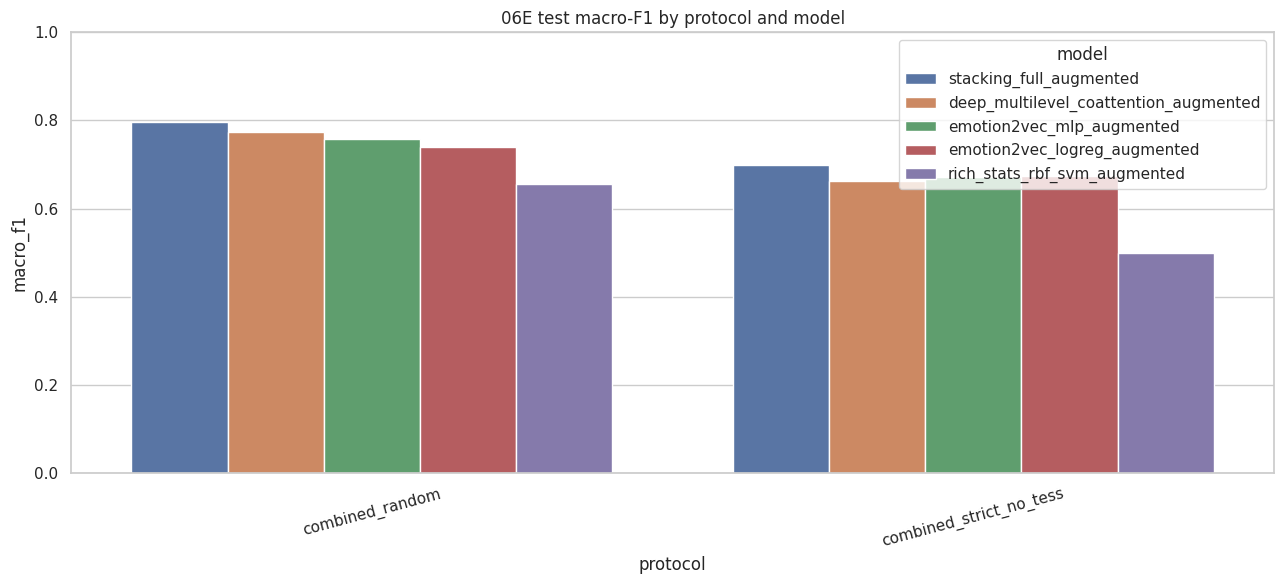

Saved: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/figures/06E_macro_f1_leaderboard.png


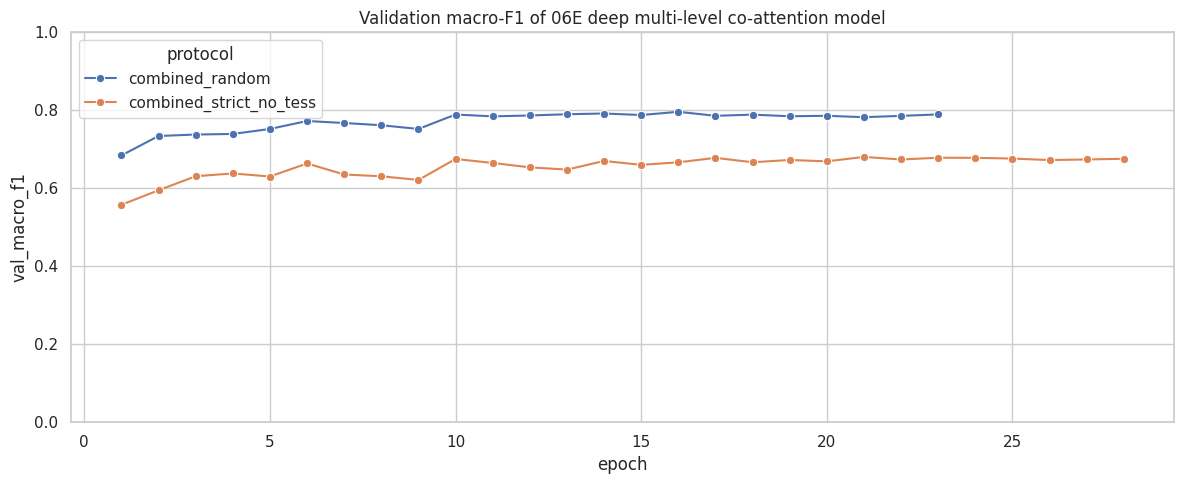

Saved: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/figures/06E_training_curves.png


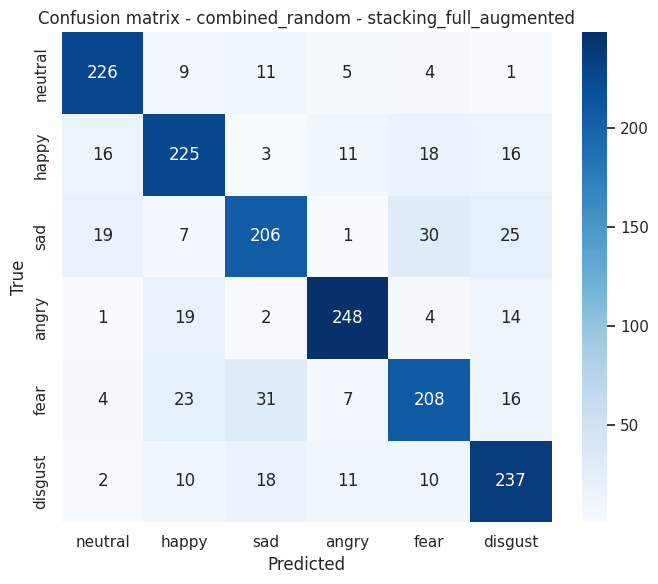

Saved: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/figures/06E_confusion_combined_random_stacking_full_augmented.png


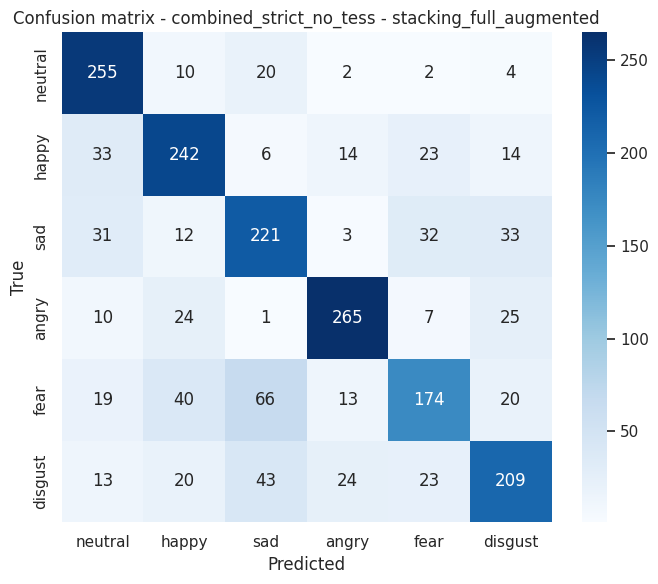

Saved: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/figures/06E_confusion_combined_strict_no_tess_stacking_full_augmented.png


In [15]:
if len(metrics_df):
    plt.figure(figsize=(13, 6))
    plot_df = metrics_df[metrics_df["split"].eq("test")].copy()
    sns.barplot(data=plot_df, x="protocol", y="macro_f1", hue="model")
    plt.ylim(0, 1)
    plt.title("06E test macro-F1 by protocol and model")
    plt.xticks(rotation=15)
    plt.tight_layout()
    fig_path = FIGURE_DIR / "06E_macro_f1_leaderboard.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)

if len(history_df):
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=history_df, x="epoch", y="val_macro_f1", hue="protocol", marker="o")
    plt.ylim(0, 1)
    plt.title("Validation macro-F1 of 06E deep multi-level co-attention model")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "06E_training_curves.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)

for protocol_name, result_pack in protocol_results.items():
    result = result_pack["stacking"]
    cm = confusion_matrix(result["y_true"], result["y_pred"], labels=list(range(len(COMMON_EMOTIONS))))
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=COMMON_EMOTIONS, yticklabels=COMMON_EMOTIONS)
    plt.title(f"Confusion matrix - {protocol_name} - stacking_full_augmented")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    fig_path = FIGURE_DIR / f"06E_confusion_{protocol_name}_stacking_full_augmented.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)


In [16]:
reference_rows = [
    {
        "model": "Ahmed et al. weighted ensemble 1D-CNN + CNN-LSTM + CNN-GRU",
        "protocol": "single-dataset, split not clearly strict speaker-aware",
        "reported_accuracy_text": "TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CREMA-D 90.47%",
        "main_idea": "Handcrafted features, waveform augmentation, recurrent CNN variants, weighted ensemble.",
        "link": "https://arxiv.org/abs/2112.05666",
    },
    {
        "model": "CA-MSER co-attention multi-level acoustic information",
        "protocol": "IEMOCAP speaker-independent style in paper; not same as our 4-corpus setup",
        "reported_accuracy_text": "Reported on IEMOCAP; use as fusion reference, not direct 6-class benchmark.",
        "main_idea": "MFCC/spectrogram/high-level embedding fusion with co-attention.",
        "link": "https://arxiv.org/abs/2203.15326",
    },
    {
        "model": "emotion2vec frozen/pretrained representation",
        "protocol": "pretrained representation; downstream varies by dataset",
        "reported_accuracy_text": "Use as representation reference; not directly comparable to our split.",
        "main_idea": "Self-supervised speech emotion representation used with lightweight downstream classifier.",
        "link": "https://arxiv.org/abs/2312.15185",
    },
    {
        "model": "Ullah et al. 1D-CNN feature fusion",
        "protocol": "combined 4-dataset, split details not fully reproducible from local materials",
        "reported_accuracy_text": "CREMA-D + RAVDESS + SAVEE + TESS: 92.62%",
        "main_idea": "ZCR + energy + entropy of energy + RMS + MFCC -> 1D-CNN.",
        "link": "https://doi.org/10.1109/ICIT56493.2022.9989197",
    },
]
ref_df = pd.DataFrame(reference_rows)
ref_df.to_csv(REPORT_DIR / "06E_reference_model_comparison.csv", index=False)
display(ref_df)


,model,protocol,reported_accuracy_text,main_idea,link
0,Ahmed et al. weighted ensemble 1D-CNN + CNN-LS...,"single-dataset, split not clearly strict speak...",TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CRE...,"Handcrafted features, waveform augmentation, r...",https://arxiv.org/abs/2112.05666
1,CA-MSER co-attention multi-level acoustic info...,IEMOCAP speaker-independent style in paper; no...,"Reported on IEMOCAP; use as fusion reference, ...",MFCC/spectrogram/high-level embedding fusion w...,https://arxiv.org/abs/2203.15326
2,emotion2vec frozen/pretrained representation,pretrained representation; downstream varies b...,Use as representation reference; not directly ...,Self-supervised speech emotion representation ...,https://arxiv.org/abs/2312.15185
3,Ullah et al. 1D-CNN feature fusion,"combined 4-dataset, split details not fully re...",CREMA-D + RAVDESS + SAVEE + TESS: 92.62%,ZCR + energy + entropy of energy + RMS + MFCC ...,https://doi.org/10.1109/ICIT56493.2022.9989197


## Save Output Package

Cell cuối đóng gói report, figure, prediction và model checkpoint. Cache feature lớn không được zip mặc định để file tải về nhẹ hơn.


In [18]:
summary = {
    "notebook": "06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_SER_v2_resume_cache",
    "objective": "SER model with richer stats, train-only waveform augmentation, frozen emotion2vec, multi-level acoustic co-attention and stacking.",
    "output_dir": str(OUTPUT_DIR),
    "metrics_csv": str(REPORT_DIR / "06E_emotion2vec_multilevel_augmented_metrics.csv"),
    "history_csv": str(REPORT_DIR / "06E_emotion2vec_multilevel_augmented_history.csv"),
    "per_dataset_csv": str(REPORT_DIR / "06E_emotion2vec_multilevel_augmented_per_dataset.csv"),
    "protocols": [name for name, _ in protocols],
    "labels": COMMON_EMOTIONS,
    "emotion2vec_model": EMOTION2VEC_MODEL,
    "use_waveform_train_augmentation": USE_WAVEFORM_TRAIN_AUGMENTATION,
    "augment_copies": AUGMENT_COPIES,
    "notes": "Cache is excluded from the light zip because feature/cache .npz files were downloaded separately.",
}

REPORT_DIR.mkdir(parents=True, exist_ok=True)
with open(REPORT_DIR / "06E_emotion2vec_multilevel_augmented_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

# ZIP NHẸ: giữ reports/figures/models/predictions, bỏ qua cache.
# Không xóa CACHE_DIR để tránh mất dữ liệu nếu cần resume.
light_zip_path = PROJECT_ROOT / "06E_outputs_light_no_cache.zip"

include_dirs = {
    "reports": REPORT_DIR,
    "figures": FIGURE_DIR,
    "models": MODEL_DIR,
    "predictions": PRED_DIR,
}

with zipfile.ZipFile(light_zip_path, "w", compression=zipfile.ZIP_DEFLATED, allowZip64=True) as zf:
    for folder_name, folder in include_dirs.items():
        folder = Path(folder)
        if not folder.exists():
            print(f"Skip missing folder: {folder_name} -> {folder}")
            continue

        file_count = 0
        for file_path in folder.rglob("*"):
            if file_path.is_file():
                arcname = file_path.relative_to(OUTPUT_DIR)
                zf.write(file_path, arcname)
                file_count += 1

        print(f"Added {folder_name}: {file_count} files")

# Kiểm tra zip có bị hỏng không ngay trên Kaggle trước khi tải về.
with zipfile.ZipFile(light_zip_path, "r") as zf:
    bad_file = zf.testzip()
    zip_files = zf.namelist()

print("LIGHT ZIP:", light_zip_path)
print("ZIP size MB:", round(light_zip_path.stat().st_size / (1024 * 1024), 2))
print("ZIP integrity:", "OK" if bad_file is None else f"BAD FILE: {bad_file}")
print("Total files in zip:", len(zip_files))
print("First files:", zip_files[:20])
print("Download this zip from Kaggle Output panel.")
light_zip_path

Deleting CACHE_DIR before packaging because cache .npz files were already downloaded: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs/cache
LIGHT ZIP without cache: /kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs_light_no_cache.zip
Cache was deleted before packaging: True
On Kaggle, open the right Output panel and download the light zip.


PosixPath('/kaggle/working/06E_Emotion2Vec_MultiLevel_CoAttention_Augmented_outputs_light_no_cache.zip')